In [2]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys
project_root = pathlib.Path.cwd().parent / 'Python'
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import ISRUtilities as isru
import modelsCNN as models

import numpy as np
import fmatoolbox as fma
import torch
import sklearn as sk
import joblib

froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [3]:
session = fma.data.readBatchFile(batch_file)[0][8]
print(session)

/mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml


In [4]:
def couplData(session,regs):

    R = fma.regions.regions(session,load_spikes=False)
    channels = np.sort(R.channels(regs))
    events = isru.loadHpcPfcEvents(session)

    # load data around ripples
    data, t = fma.data.loadWideband(session,channels=channels,intervals=events['ripples'][:,None]-[0.5,0.05],cat=False)
    n_samples = min([len(d) for d in data])
    data = np.stack([d[:n_samples].T for d in data],axis=0) # (events, channels, time)
    t = np.stack([d[:n_samples] for d in t],axis=0) # (events, time)

    # smallest delta time following each event ripple
    idx = np.searchsorted(events['deltaWaves'],events['ripples'],side='right')
    valid = idx < len(events['deltaWaves'])
    distance = np.full_like(events['ripples'],np.nan,dtype=float)
    distance[valid] = events['deltaWaves'][idx[valid]] - events['ripples'][valid]
    valid = ~np.isnan(distance)
    data = data[valid]
    distance = distance[valid]

    return data, distance

In [4]:
def _couplingRidge(session,regs):
    # compute learning curve for regression on wideband data

    X, y = couplData(session,regs)
    X = X.reshape(X.shape[0],-1) # (events, channels * time)

    model = sk.pipeline.Pipeline([
            ("pca", sk.decomposition.PCA(n_components=100)), # (previous test shows that ~70 PCs explain 95% of the variance)
            ("ridge", sk.linear_model.RidgeCV(alphas=np.logspace(-2,5,20)))])
    train_sizes_abs, train_scores, test_scores = sk.model_selection.learning_curve(model,X,y,scoring="r2",verbose=2)
    results = {"model": model,
               "train_sizes": train_sizes_abs,
               "train_scores": train_scores,
               "test_scores": test_scores,}
    joblib.dump(results, "Results/RidgeCV.joblib")

    return results

In [21]:
ridge_cv = _couplingRidge(session,'pfc')

[learning_curve] Training set sizes: [ 267  868 1469 2070 2672]


[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:  5.4min finished


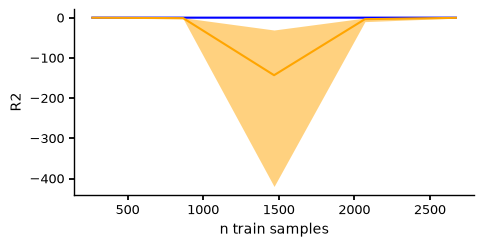

In [11]:
ridge_cv = joblib.load("Results/RidgeCV.joblib")
fig, ax = fma.plotting.makeFigure(size=(12,6))
fma.plotting.semPlot(ridge_cv["train_sizes"],ridge_cv["train_scores"],color='b')
fma.plotting.semPlot(ridge_cv["train_sizes"],ridge_cv["test_scores"],color='orange')
ax[0].set(xlabel='n train samples',ylabel='R2');

In [4]:
def _couplingCNN(session,regs,model="CNN1d",train_sizes=None,rnd_seed=None):

    # configure GPU use
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"device: {device}")

    X, y = couplData(session,regs)
    X = torch.tensor(X,dtype=torch.float32)
    y = torch.tensor(y,dtype=torch.float32)

    mod = model
    kf = sk.model_selection.KFold(n_splits=5,shuffle=True,random_state=rnd_seed)
    kf = kf.split(X)
    train_losses = []
    test_losses = []
    val_losses = []
    print("fold  -  validation Huber loss")
    for fold, (train_idx, val_idx) in enumerate(kf):
        if train_sizes is None: train_sizes = [len(train_idx)]
        print(f"  {fold+1}   -",end="")

        train_losses.append([])
        test_losses.append([])
        val_losses.append([])
        for n in train_sizes:
            this_train_idx = train_idx[:n]

            # split into train and validation sets
            X_train = X[this_train_idx]
            y_train = y[this_train_idx]
            X_val = X[val_idx]
            y_val = y[val_idx]

            # normalize
            m = X_train.mean(dim=(0,2),keepdim=True)
            s = X_train.std(dim=(0,2),keepdim=True)
            X_train = (X_train - m) / s
            X_val = (X_val - m) / s

            # repeat data for epochs
            train_ds = torch.utils.data.TensorDataset(X_train,y_train)
            val_ds = torch.utils.data.TensorDataset(X_val,y_val)
            train_loader = torch.utils.data.DataLoader(train_ds,batch_size=16,shuffle=True)
            val_loader = torch.utils.data.DataLoader(val_ds,batch_size=16,shuffle=False)

            # define / reset model
            match mod:
                case "CNN1d":
                    model = models.CNN1D(n_features=X.shape[1]).to(device)
                case "CNN1d_dilation":
                    model = models.CNN1D_dilation(n_features=X.shape[1]).to(device)
            optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4) # weight_decay against overfitting
            #criterion = torch.nn.MSELoss()
            criterion = torch.nn.HuberLoss() # better for nonnegative target

            # training
            y_true = []
            y_pred = []
            for epoch in range(100):
                model.train()
                for xb, yb in train_loader:
                    y_true.append(yb.numpy())
                    xb = xb.to(device)
                    yb = yb.to(device)
                    optimizer.zero_grad()
                    pred = model(xb)
                    loss = criterion(pred,yb)
                    loss.backward()
                    optimizer.step()
                    y_pred.append(pred.cpu().detach().numpy())
            train_losses[-1].append(sk.metrics.r2_score(np.concatenate(y_true), np.concatenate(y_pred)))

            # validation
            model.eval()
            y_true = []
            y_pred = []
            this_val_losses = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    y_true.append(yb.numpy())
                    xb = xb.to(device)
                    yb = yb.to(device)
                    pred = model(xb)
                    loss = criterion(pred,yb)
                    this_val_losses.append(loss.item())
                    y_pred.append(pred.cpu().detach().numpy())
            test_losses[-1].append(sk.metrics.r2_score(np.concatenate(y_true), np.concatenate(y_pred)))

        mean_val_loss = np.mean(this_val_losses)
        print(f"  {mean_val_loss:.4f}")
        val_losses[-1].append(mean_val_loss.item())

        results = {"train_sizes": train_sizes,
                   "train_scores": train_losses,
                   "test_scores": test_losses,
                   "val_losses": val_losses}
        joblib.dump(results, f"Results/{mod}.joblib")

    return results

In [5]:
ridge_cv = joblib.load("Results/RidgeCV.joblib")
CNN_dil_cv = _couplingCNN(session,'pfc',model='CNN1d_dilation',train_sizes=ridge_cv['train_sizes'],rnd_seed=42)

device: cuda
fold  -  validation Huber loss
  1   -  25.4922
  2   -  18.7296
  3   -  23.1030
  4   -  18.0744
  5   -  21.1941


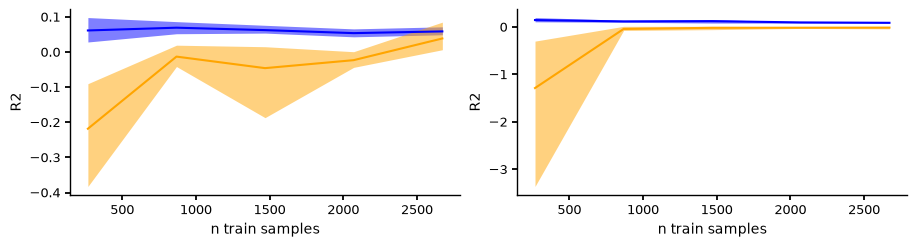

In [5]:
fig, ax = fma.plotting.makeFigure(n=(1,2),size=(23,6))

cnn1d_cv = joblib.load("Results/CNN1d.joblib")
fma.plotting.semPlot(cnn1d_cv["train_sizes"],cnn1d_cv["train_scores"],color='b',ax=ax[0])
fma.plotting.semPlot(cnn1d_cv["train_sizes"],cnn1d_cv["test_scores"],color='orange',ax=ax[0])
ax[0].set(xlabel='n train samples',ylabel='R2');

cnn1d_cv = joblib.load("Results/CNN1d_dilation.joblib")
fma.plotting.semPlot(cnn1d_cv["train_sizes"],cnn1d_cv["train_scores"],color='b',ax=ax[1])
fma.plotting.semPlot(cnn1d_cv["train_sizes"],cnn1d_cv["test_scores"],color='orange',ax=ax[1])
ax[1].set(xlabel='n train samples',ylabel='R2');

In [ ]:
_couplingCNN(session)

/mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml
cuda
fold 1
Validation MSE: 161.3512
fold 2
Validation MSE: 81.7770
fold 3
Validation MSE: 125.0528
fold 4
Validation MSE: 71.4129
fold 5
Validation MSE: 61.0134


[np.float64(161.35120897130534),
 np.float64(81.77700426361777),
 np.float64(125.05283264680342),
 np.float64(71.41288946975361),
 np.float64(61.013405962423846)]

In [ ]:
print(torch.version.cuda)
print(torch.backends.cudnn.enabled)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

13.0
True
True
NVIDIA RTX 5000 Ada Generation
